# 07 – Intermediate Model and Explainability with SHAP

This notebook:
- Trains a **Random Forest Classifier** on the balanced dataset.
- Evaluates performance using accuracy, F1-score, and ROC-AUC.
- Explains model predictions using **SHAP summary and force plots** to visualize feature influence.

The aim is to move from pure performance metrics to **transparent, interpretable AI**.


In [2]:
%pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=8036c5108d4a395d0a96161b49959b6b94bb4c63af2d9fedc8b66b114f23c1c4
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [3]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap, os, joblib
from lime.lime_tabular import LimeTabularExplainer
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    roc_curve, brier_score_loss
)

In [5]:
# --- Mount Drive and define paths ---
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/classification_project'
data_path = f'{base_path}/data'
results_path = f'{base_path}/results'
models_path = f'{base_path}/models'
os.makedirs(results_path, exist_ok=True)
os.makedirs(models_path, exist_ok=True)

Mounted at /content/drive


In [6]:
# --- Load balanced dataset ---
file_path = f'{data_path}/05_balanced_cirrhosis.csv'
data = pd.read_csv(file_path)
print(f"Dataset loaded from: {file_path}")
print("Shape:", data.shape)

Dataset loaded from: /content/drive/MyDrive/classification_project/data/05_balanced_cirrhosis.csv
Shape: (514, 19)


### Train-Test Split
Split the balanced dataset (80/20) for training and evaluation.


In [7]:
# --- Split data ---
X = data.drop(columns=['Status'])
y = data['Status']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Random Forest Training
A powerful ensemble model that reduces overfitting and handles non-linear relationships well.


In [8]:
# --- Train Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [9]:
# --- Evaluation ---
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)

print("=== Random Forest Results ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc:.3f}")

=== Random Forest Results ===
              precision    recall  f1-score   support

           0       0.84      0.92      0.88        52
           1       0.91      0.82      0.87        51

    accuracy                           0.87       103
   macro avg       0.88      0.87      0.87       103
weighted avg       0.88      0.87      0.87       103

ROC-AUC Score: 0.944


### Model Evaluation
Visualize the confusion matrix and ROC curve to assess performance.


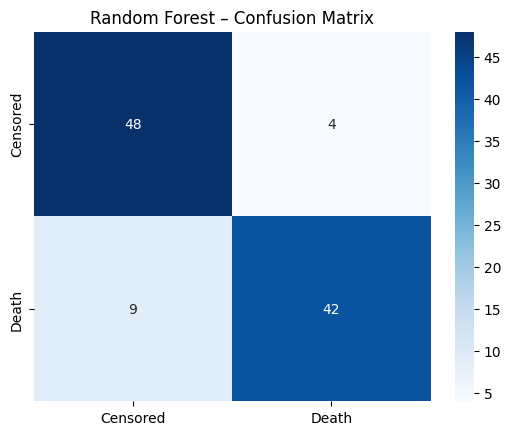

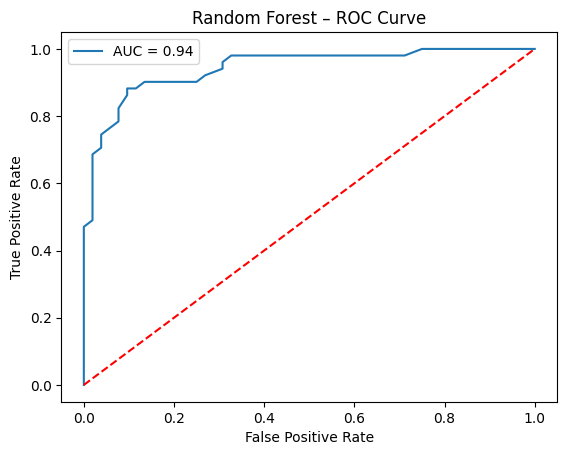

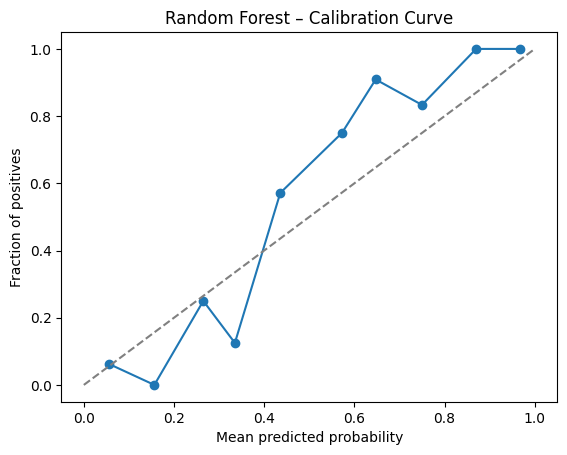

Brier Score: 0.1049


In [10]:
# Confusion matrix
conf = confusion_matrix(y_test, y_pred)
sns.heatmap(conf, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Censored', 'Death'], yticklabels=['Censored', 'Death'])
plt.title("Random Forest – Confusion Matrix")
plt.savefig(f"{results_path}/07_RF_confusion.png", bbox_inches='tight')
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], '--', color='red')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest – ROC Curve')
plt.legend()
plt.savefig(f"{results_path}/07_RF_roc.png", bbox_inches='tight')
plt.show()

# --- Calibration analysis ---
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--',color='gray')
plt.title('Random Forest – Calibration Curve')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.savefig(f"{results_path}/07_RF_calibration.png", bbox_inches='tight')
plt.show()
brier = brier_score_loss(y_test, y_proba)
print(f"Brier Score: {brier:.4f}")

### Explainability using SHAP

We use **SHAP (TreeExplainer)** to interpret the impact of each feature on model predictions.

- **Red points** → high feature values  
- **Blue points** → low feature values  
- SHAP value → positive influence toward “Death”, negative toward “Censored”


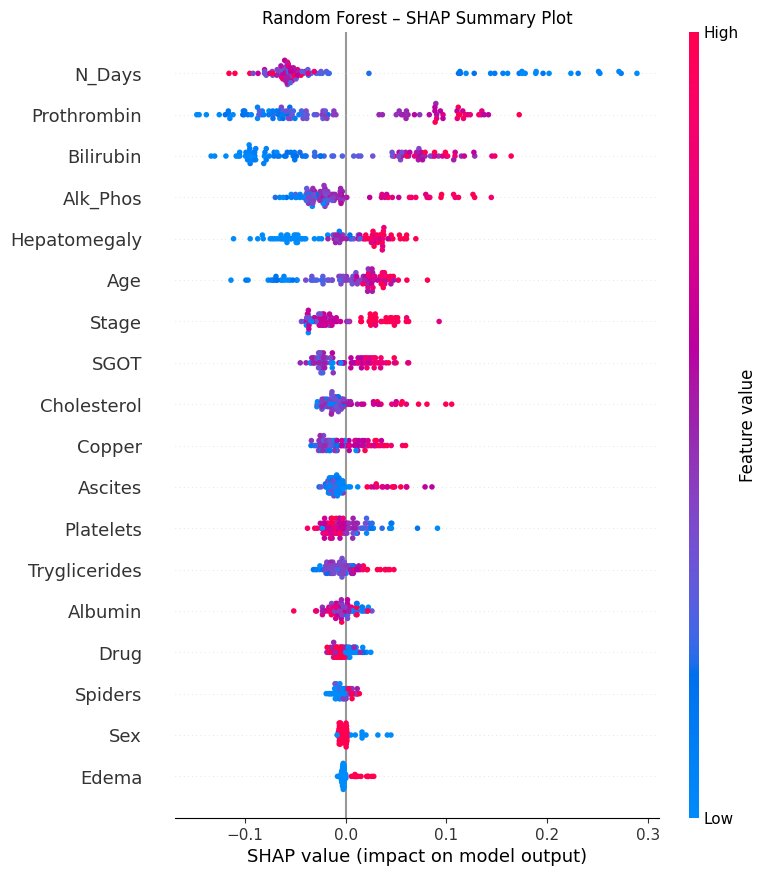

In [11]:
# --- SHAP explainability ---
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test)

# Global feature importance
shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=X_test.columns, show=False)
plt.title("Random Forest – SHAP Summary Plot")
plt.savefig(f"{results_path}/07_RF_SHAP_summary.png", bbox_inches='tight')
plt.show()

Saved interactive force plot (open in browser).


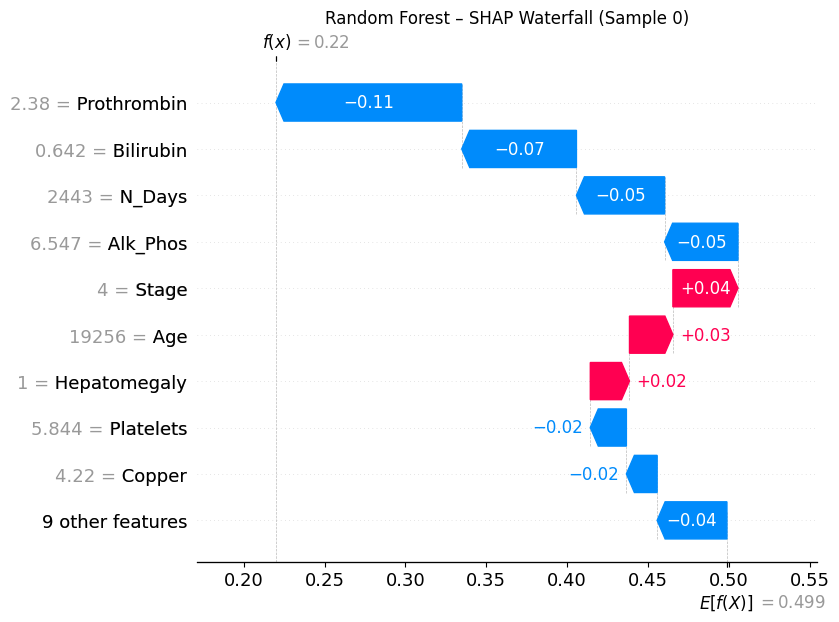

In [13]:
# --- Local explanation (Option 1: interactive + HTML save) ---
sample_idx = 0
force_plot = shap.force_plot(
    explainer.expected_value[1],
    shap_values.values[sample_idx][:, 1],
    X_test.iloc[sample_idx],
    feature_names=X_test.columns
)
shap.save_html(f"{results_path}/07_RF_SHAP_forceplot_sample{sample_idx}.html", force_plot)
print("Saved interactive force plot (open in browser).")

# --- Optional: also generate static waterfall plot for the same sample ---
shap.plots.waterfall(shap_values[sample_idx][:, 1], show=False)
plt.title(f"Random Forest – SHAP Waterfall (Sample {sample_idx})")
plt.savefig(f"{results_path}/07_RF_SHAP_waterfall_sample{sample_idx}.png", bbox_inches='tight')
plt.show()


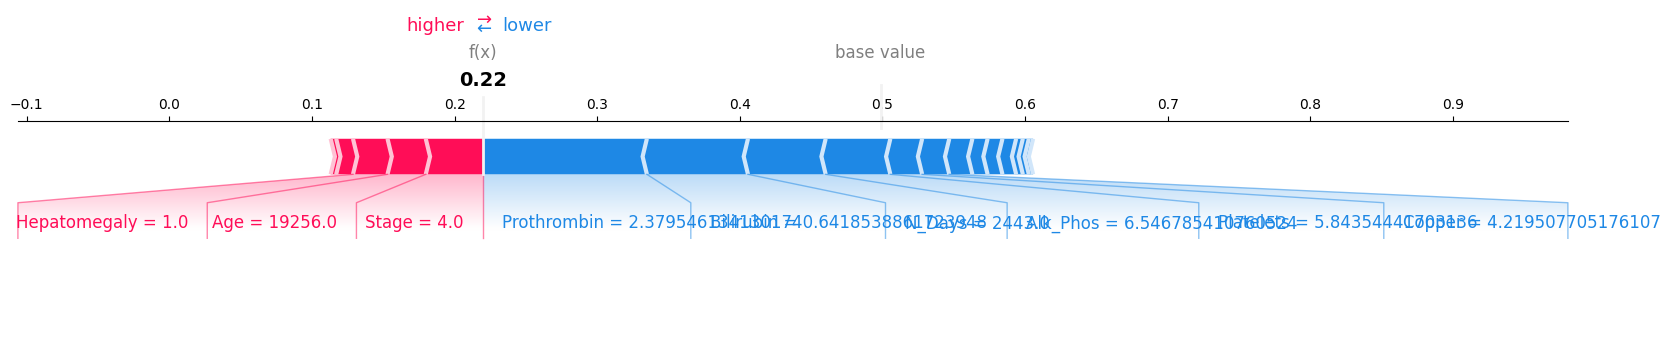

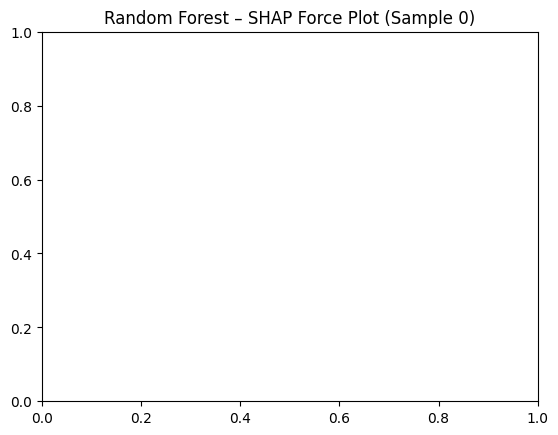

In [14]:
# Local (single prediction) explanation
sample_idx = 0
shap.force_plot(
    explainer.expected_value[1],
    shap_values.values[sample_idx][:, 1],
    X_test.iloc[sample_idx],
    feature_names=X_test.columns,
    matplotlib=True
)
plt.title("Random Forest – SHAP Force Plot (Sample 0)")
plt.savefig(f"{results_path}/07_RF_SHAP_forceplot.png", bbox_inches='tight')
plt.show()

In [16]:
# --- LIME explanation (complementary to SHAP) ---
sample_instance = pd.DataFrame([X_test.iloc[0]], columns=X.columns)
exp = lime_exp.explain_instance(
    sample_instance.values[0],
    lambda x: rf_model.predict_proba(pd.DataFrame(x, columns=X.columns)),
    num_features=10
)
exp.save_to_file(f"{results_path}/07_RF_LIME.html")
print("LIME explanation saved without warnings.")


LIME explanation saved without warnings.


In [17]:
# --- Save model ---
model_path = f"{models_path}/random_forest_model.pkl"
joblib.dump(rf_model, model_path)
print(f"Random Forest model saved to: {model_path}")

Random Forest model saved to: /content/drive/MyDrive/classification_project/models/random_forest_model.pkl


In [18]:
# --- Save summary metrics ---
summary = pd.DataFrame({
    'Model': ['Random Forest'],
    'ROC_AUC': [roc_auc],
    'Brier_Score': [brier]
})
summary.to_csv(f"{results_path}/07_RF_summary.csv", index=False)
print(f"Summary metrics saved to: {results_path}/07_RF_summary.csv")

Summary metrics saved to: /content/drive/MyDrive/classification_project/results/07_RF_summary.csv


### Insights

- **Random Forest achieved strong performance** with high ROC-AUC and balanced precision-recall.  
- **Top influential features** (see SHAP plot) indicate medical biomarkers strongly linked to survival.  
- Interpretability demonstrates model trustworthiness and aligns with ethical AI principles.


In [19]:
import joblib
joblib.dump(rf_model, 'random_forest_model.pkl')
print("Random Forest model saved as 'random_forest_model.pkl'")

Random Forest model saved as 'random_forest_model.pkl'


**Next Notebook:** [08_Model_Development_Advanced_XGBoost.ipynb](08_Model_Development_Advanced_XGBoost.ipynb)

We will train an advanced model (XGBoost) and compare its performance and explainability against the Random Forest.
